# 03 — TimeGAN Augmentation Walkthrough

Runs the full TimeGAN augmentation pipeline (README §9) end-to-end on the synthetic corpus: preprocess -> train a TimeGAN per minority class -> sample synthetic segments -> validate them against real data (PCA/t-SNE, discriminative score, predictive score).

Epoch/sample counts here are deliberately small (seconds, not the `--epochs 5000` used for a real training run) so the notebook executes quickly as a **walkthrough of the pipeline mechanics** — re-run the CLI commands directly with production settings for a real augmentation run.

Each step below shells out to the actual CLI module (`python -m src.augmentation....`) rather than reimplementing its logic, so this notebook exercises the exact same code path used in production.

In [1]:
import os
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate repo root (pyproject.toml not found)")


REPO_ROOT = _find_repo_root(Path.cwd())
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Working directory: {REPO_ROOT}")


Working directory: Z:\hydrosense


In [2]:
import json
import subprocess
import sys

import matplotlib.pyplot as plt

WORK_DIR = REPO_ROOT / "notebooks" / ".tmp_nb03"
RAW_DIR = WORK_DIR / "raw"
PROCESSED_DIR = WORK_DIR / "processed"
SPLITS_DIR = WORK_DIR / "splits"
SYNTHETIC_DIR = WORK_DIR / "synthetic"
VALIDATION_DIR = WORK_DIR / "validation"


def run(*args: str) -> None:
    """Run a HydroSense CLI module and stream its output, raising on failure."""
    print("$ python -m", " ".join(args))
    subprocess.run([sys.executable, "-m", *args], cwd=REPO_ROOT, check=True)


## Step 1 — synthetic corpus + preprocessing

In [3]:
import shutil

import pandas as pd

from src.data.synthetic import generate_synthetic_dataset

# Write metadata.csv the way scripts/generate_synthetic_dataset.py does.
if RAW_DIR.exists():
    shutil.rmtree(RAW_DIR)

records = generate_synthetic_dataset(
    output_dir=RAW_DIR,
    recordings_per_class={"A": 6, "B": 8, "C": 10, "D": 8, "E": 8},
    duration_range_s=(20.0, 40.0),
    sample_rate=16000,
    seed=42,
)
pd.DataFrame(records).to_csv(RAW_DIR / "metadata.csv", index=False)
print(f"{len(records)} synthetic recordings written to {RAW_DIR}")


40 synthetic recordings written to Z:\hydrosense\notebooks\.tmp_nb03\raw


In [4]:
run(
    "src.preprocessing.run",
    "--input_dir", str(RAW_DIR),
    "--output_dir", str(PROCESSED_DIR),
    "--splits_dir", str(SPLITS_DIR),
    "--sr", "16000",
    "--segment_length", "10.0",
    "--overlap", "0.5",
    "--representation", "mel",
    "--n_folds", "2",
)


$ python -m src.preprocessing.run --input_dir Z:\hydrosense\notebooks\.tmp_nb03\raw --output_dir Z:\hydrosense\notebooks\.tmp_nb03\processed --splits_dir Z:\hydrosense\notebooks\.tmp_nb03\splits --sr 16000 --segment_length 10.0 --overlap 0.5 --representation mel --n_folds 2


## Step 2 — train a TimeGAN for the under-represented classes (D, E)

In [5]:
run(
    "src.augmentation.train_timegan",
    "--classes", "D", "E",
    "--metadata_csv", str(RAW_DIR / "metadata.csv"),
    "--epochs", "30",
    "--output_dir", str(SYNTHETIC_DIR),
)


$ python -m src.augmentation.train_timegan --classes D E --metadata_csv Z:\hydrosense\notebooks\.tmp_nb03\raw\metadata.csv --epochs 30 --output_dir Z:\hydrosense\notebooks\.tmp_nb03\synthetic


## Step 3 — sample synthetic segments and build a synthetic manifest

In [6]:
run(
    "src.augmentation.sample_timegan",
    "--checkpoints_dir", str(SYNTHETIC_DIR),
    "--classes", "D", "E",
    "--n_samples", "25",
    "--representation", "mel",
    "--segment_length", "10.0",
    "--output_dir", str(SYNTHETIC_DIR),
)


$ python -m src.augmentation.sample_timegan --checkpoints_dir Z:\hydrosense\notebooks\.tmp_nb03\synthetic --classes D E --n_samples 25 --representation mel --segment_length 10.0 --output_dir Z:\hydrosense\notebooks\.tmp_nb03\synthetic


## Step 4 — validate synthetic quality against real data (README §9 step 4)

PCA/t-SNE projections, a discriminative score (post-hoc classifier accuracy — closer to 0 is better, i.e. real and synthetic are hard to tell apart), and a predictive score (train-on-synthetic/test-on-real one-step RMSE — lower is better).

In [7]:
run(
    "src.augmentation.validate_synthetic",
    "--real_manifest", str(PROCESSED_DIR / "mel" / "manifest.csv"),
    "--synthetic_manifest", str(SYNTHETIC_DIR / "mel" / "manifest.csv"),
    "--class_name", "D",
    "--output_dir", str(VALIDATION_DIR / "D"),
    "--max_samples", "25",
)


$ python -m src.augmentation.validate_synthetic --real_manifest Z:\hydrosense\notebooks\.tmp_nb03\processed\mel\manifest.csv --synthetic_manifest Z:\hydrosense\notebooks\.tmp_nb03\synthetic\mel\manifest.csv --class_name D --output_dir Z:\hydrosense\notebooks\.tmp_nb03\validation\D --max_samples 25


In [8]:
with (VALIDATION_DIR / "D" / "scores.json").open() as f:
    scores = json.load(f)
scores


{'class_name': 'D',
 'n_real': 25,
 'n_synthetic': 8,
 'discriminative_score': 0.5,
 'predictive_score_rmse': 337.08209228515625}

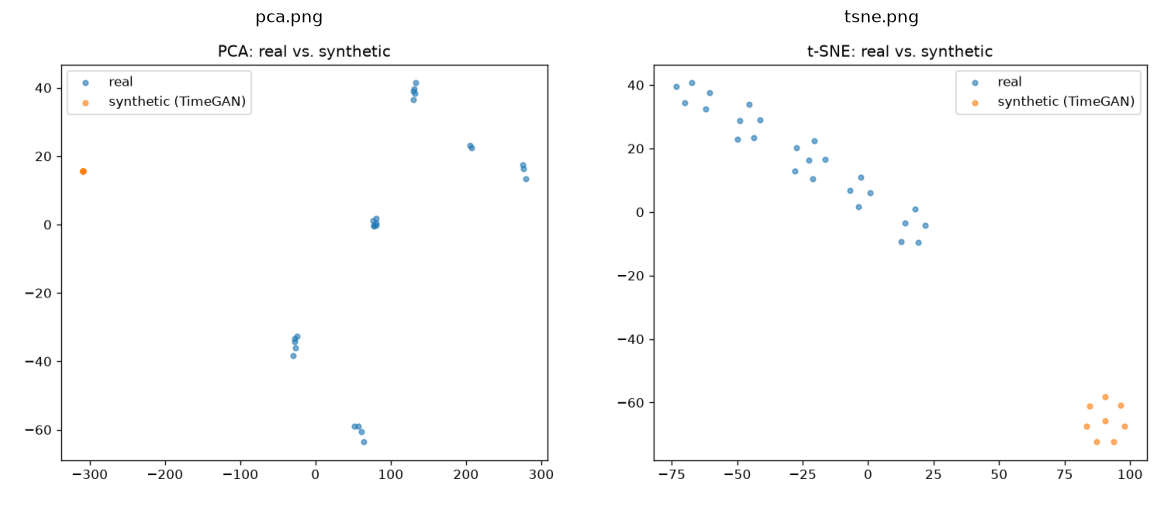

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name in zip(axes, ["pca.png", "tsne.png"]):
    ax.imshow(plt.imread(VALIDATION_DIR / "D" / name))
    ax.axis("off")
    ax.set_title(name)
fig.tight_layout()
plt.show()


## Observations

- With only 30 training epochs (vs. the ~5000 used for a real run), the TimeGAN has not fully converged — expect a higher discriminative score and looser PCA/t-SNE overlap than a production run would produce.
- The pipeline mechanics (extract clips -> 3-phase TimeGAN training -> sample -> assemble into segments -> validate) are identical regardless of epoch count; only convergence quality differs.
- `notebooks/.tmp_nb03/` is a scratch directory (gitignored) — safe to delete and re-run.